In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

print(f"Setup Complete.")

Setup Complete.


In [3]:
def print_wo_br(np_array: np.ndarray) -> str:
    """Simply converts the passed np.array to a str, with no max line with, suppressing line breaks in the output."""
    return np.array2string(np_array, max_line_width=np.inf)

In [4]:
# my test trial [15, 14, 3, 3, 1, 3, 8, 1, 1, 14],
trials = np.array(
    [
        [8, 2, 6, 3, 1, 1, 2, 4, 1, 1],
        [2, 3, 3, 5, 4, 6, 4, 4, 6, 1],
        [8, 5, 6, 1, 3, 4, 1, 1, 12, 14],
        [9, 18, 11, 19, 3, 14, 2, 4, 7, 2],
        [3, 2, 3, 5, 6, 1, 5, 9, 19, 11],
        [1, 9, 8, 3, 23, 1, 1, 1, 4, 1],
        [3, 1, 8, 1, 3, 3, 5, 5, 4, 1],
        [6, 1, 2, 20, 1, 4, 1, 8, 1, 1],
        [4, 8, 1, 4, 4, 3, 1, 1, 2, 13],
        [3, 4, 4, 3, 2, 1, 5, 2, 1, 4],
        [11, 4, 5, 7, 12, 15, 19, 1, 8, 16],
        [19, 7, 14, 10, 1, 20, 1, 3, 2, 2],
    ],
)
trials.shape

(12, 10)

In [5]:
trials

array([[ 8,  2,  6,  3,  1,  1,  2,  4,  1,  1],
       [ 2,  3,  3,  5,  4,  6,  4,  4,  6,  1],
       [ 8,  5,  6,  1,  3,  4,  1,  1, 12, 14],
       [ 9, 18, 11, 19,  3, 14,  2,  4,  7,  2],
       [ 3,  2,  3,  5,  6,  1,  5,  9, 19, 11],
       [ 1,  9,  8,  3, 23,  1,  1,  1,  4,  1],
       [ 3,  1,  8,  1,  3,  3,  5,  5,  4,  1],
       [ 6,  1,  2, 20,  1,  4,  1,  8,  1,  1],
       [ 4,  8,  1,  4,  4,  3,  1,  1,  2, 13],
       [ 3,  4,  4,  3,  2,  1,  5,  2,  1,  4],
       [11,  4,  5,  7, 12, 15, 19,  1,  8, 16],
       [19,  7, 14, 10,  1, 20,  1,  3,  2,  2]])

In [6]:
np.mean(trials)  # overall mean for all observations and trials

np.float64(5.441666666666666)

In [7]:
trials[:, 9]  # the 9th (10th) column of trials

array([ 1,  1, 14,  2, 11,  1,  1,  1, 13,  4, 16,  2])

In [8]:
mean_0 = np.mean(
    trials, axis=0
)  # axis=0 means column-wise mean, such that each entry in this 10-element array is the mean of that column of observations
mean_1 = np.mean(
    trials, axis=1
)  # axis=1 means row-wise mean, such that each entry in this 12-element array is the mean of that row of observations
print(
    f"The mean for axis 0 (ie. column-wise mean) is\n{print_wo_br(mean_0)}\nand the mean for axis 1 (ie. row-wise mean) is\n{mean_1}."
)
print(
    f"For our purposes, the average number of rolls to get a 6 (for each set of 10 rolls) is given by the mean on axis 1:\n{mean_1}."
)

The mean for axis 0 (ie. column-wise mean) is
[6.41666667 5.33333333 5.91666667 6.75       5.25       6.08333333 3.91666667 3.58333333 5.58333333 5.58333333]
and the mean for axis 1 (ie. row-wise mean) is
[2.9 3.8 5.5 8.9 6.4 5.2 3.4 4.5 4.1 2.9 9.8 7.9].
For our purposes, the average number of rolls to get a 6 (for each set of 10 rolls) is given by the mean on axis 1:
[2.9 3.8 5.5 8.9 6.4 5.2 3.4 4.5 4.1 2.9 9.8 7.9].


In [9]:
hist_all, bin_edges = np.histogram(mean_1, bins=15)
hist_all, bin_edges

(array([2, 2, 1, 1, 0, 2, 0, 1, 0, 0, 1, 0, 0, 1, 1]),
 array([2.9 , 3.36, 3.82, 4.28, 4.74, 5.2 , 5.66, 6.12, 6.58, 7.04, 7.5 ,
        7.96, 8.42, 8.88, 9.34, 9.8 ]))

Text(0.5, 1.0, 'Histogram of Rolls to Get a 6 over 12 Trials of 10 Rolls each')

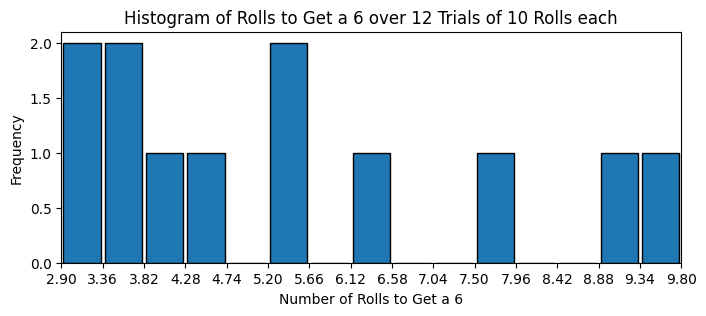

In [10]:
# plt.hist(hist_all, bins=[0, 30]) # chokes magnificently, barfing out the histogram full of the fill color

# plt.hist(hist_all, bins=bin_edges) # seemingly the inverse of the above, spits out histogram with nothing of the fill color (looks like no data)

# from SO: https://stackoverflow.com/a/9141911
# to plot histogram data as a bar chart, this is closest I've found to a proper histogram somehow
# plt.bar(bin_edges[:-1], hist_all)

# to plot histogram as a continuous line plot
# fig, ax = plt.subplots()
# ax.plot(bin_edges[:-1], hist_all)

# from SO: https://stackoverflow.com/a/5328669
# to calculate the proper width and center for the bins
# width = np.diff(bin_edges) # automatically calculates the width of each bin, at 100% bin width, so bars touch each other
width = 0.9 * (
    bin_edges[1] - bin_edges[0]
)  # width of each bar is 90% of the bin width, giving slight gaps visually
center = (bin_edges[:-1] + bin_edges[1:]) / 2
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xticks(bin_edges)  # set x-ticks to be at the bin edges
ax.bar(center, hist_all, align="center", width=width, edgecolor="black")


plt.xlim(min(bin_edges), max(bin_edges))
plt.xlabel("Number of Rolls to Get a 6")
plt.ylabel("Frequency")
plt.title("Histogram of Rolls to Get a 6 over 12 Trials of 10 Rolls each")


# Interpretation
We can see from the bar plot/histogram above, that with our 12 observations of 10 rolls each, the average for each set of observations is plotted in the histogram. From the data, we can see that /most/ observation trials had a typically lower average of ~2-4 (approximate values due to noninteger bin edges). While this data certainly doesn't look like any identifiable distribution due to the low count of observations, this data should resemble a geometric distribution. This would also represent a skewed-right distribution, as the mean of a fair 6-sided die is $$ \mu = \frac{1}{6}\sum_{i=1}^{6} i = 3.5 $$ and we'd expect the results to cluster near this mean, and trailing off to the right. However, with more observations (e.g. 1000 or more), the histogram would better resemble a geometric distribution.

In [11]:
p_success = 1 / 6
num_of_trials = 12
num_of_simulations = (
    1000  # couldn't identify the shape of the dist with n=10, so let's try n=1000
)
trials_simulated = np.random.geometric(p_success, (num_of_simulations, num_of_trials))
print(f"{trials_simulated=}")

trials_simulated=array([[ 2,  6,  2, ...,  4,  5,  3],
       [ 5, 12,  1, ...,  7,  3, 23],
       [10,  1,  4, ...,  2,  1,  4],
       ...,
       [ 1,  2,  2, ...,  1,  5, 28],
       [28,  1,  8, ..., 14,  3,  1],
       [ 5,  3,  2, ...,  4,  5,  4]], shape=(1000, 12), dtype=int32)


Text(0.5, 1.0, 'Histogram of Rolls to Get a 6 over 1000 Trials of 12 Rolls each')

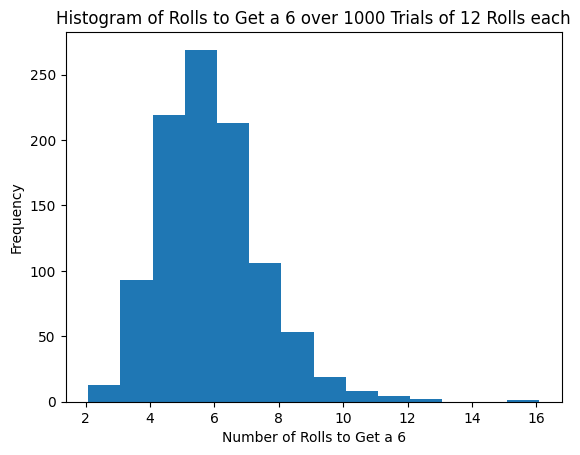

In [14]:
mean_simulated = np.mean(trials_simulated, axis=1)
# print(f"{mean_simulated=}")
hist_all_simulated, bin_edges_simulated = np.histogram(mean_simulated, bins=15)
# print(f"{hist_all_simulated=}")
# print(f"{bin_edges_simulated=}")

# that's all dandy, but arbitrary choice of 15 bins is ... eh...
# let's see if numpy can do better...
auto_bin_edges = np.histogram_bin_edges(mean_simulated, bins="auto")
# print(f"{auto_bin_edges=}")

# eh... I actually prefer our hardcoded 15, over the auto selected 6 bins...
binwidth = 1  # 3 seems reasonable
plt.hist(
    mean_simulated,
    bins=np.arange(min(mean_simulated), max(mean_simulated) + binwidth, binwidth),
)
plt.xlabel("Number of Rolls to Get a 6")
plt.ylabel("Frequency")
plt.title(f"Histogram of Rolls to Get a 6 over {num_of_simulations} Trials of {num_of_trials} Rolls each")
# That plot there resembles a geometric distribution, as expected.

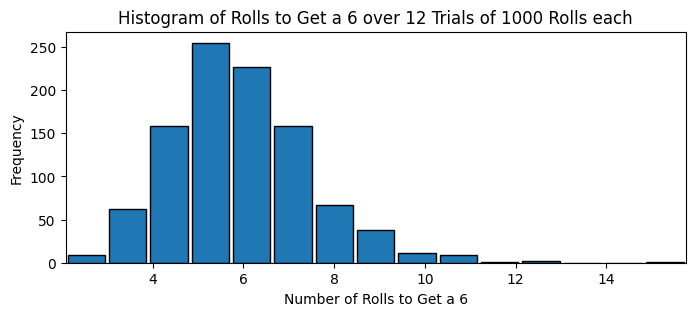

In [15]:
# calculate width of bins, and center bin points
width = 0.9 * (
    bin_edges_simulated[1] - bin_edges_simulated[0]
)  # width of each bar is 90% of the bin width, giving slight gaps visually
center = (bin_edges_simulated[:-1] + bin_edges_simulated[1:]) / 2

# enlarge figure for clarity, set the bin_edges as x-ticks
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xticks(bin_edges_simulated)  # set x-ticks to be at the bin edges
ax.bar(center, hist_all_simulated, align="center", width=width, edgecolor="black")


# set x-limits, labels, title, and integer x-ticks
plt.xlim(min(bin_edges_simulated), max(bin_edges_simulated))
plt.xlabel("Number of Rolls to Get a 6")
plt.ylabel("Frequency")
plt.title(
    f"Histogram of Rolls to Get a 6 over {num_of_trials} Trials of {num_of_simulations} Rolls each"
)
ax = fig.gca()
ax.xaxis.set_major_locator(
    MaxNLocator(integer=True)
)  # TODO Fix x-axis to show only integer ticks, probably np.arange() with bins